# Customer Churn Prediction
## Phase 2: Explore the Data
### Step 2.1: Load and Inspect Data

In [56]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/churn.csv')

In [57]:
# Display the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [58]:
# Display data types of each column
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [59]:
# Display statistical summary
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [60]:
# Count missing values per column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Step 2.2: Check Class Balance

,Count,Percentage (%)
Churn,,
No,5174,73.46
Yes,1869,26.54


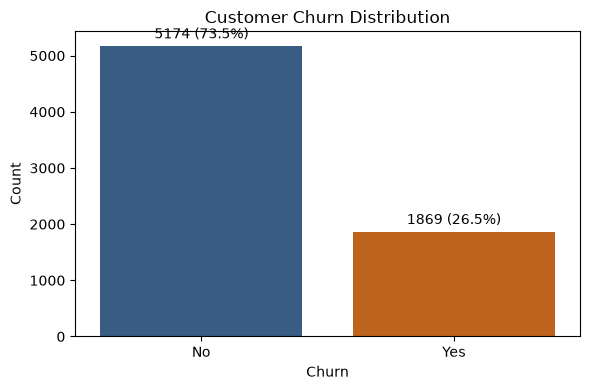

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count and percentage of churn vs non-churn
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    'Count': churn_counts,
    'Percentage (%)': churn_percentages.round(2)
})
display(churn_summary)

# Plot class balance as a bar chart
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', hue='Churn', palette=['#2b5c8f', '#d95f02'], legend=False)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')

# Annotate bars with count and percentage
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)} ({height/total:.1%})',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

## Phase 3: Clean and Prepare Data
### Step 3.1: Handle Missing Values

In [62]:
# Convert TotalCharges to numeric (blank spaces become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values were introduced
print(f"Missing values in TotalCharges before drop: {df['TotalCharges'].isnull().sum()}")

# Drop rows with missing values (11 rows where tenure is 0)
df = df.dropna(subset=['TotalCharges'])

# Confirm zero missing values remaining across the dataset
print(f"\nRemaining shape of dataset: {df.shape}")
print("\nMissing values count per column:")
print(df.isnull().sum())


Missing values in TotalCharges before drop: 11

Remaining shape of dataset: (7032, 21)

Missing values count per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Step 3.2: Encode Categorical Columns
- Remove the `customerID` column as it is an arbitrary identifier not useful for predictive modeling.
- Convert all categorical/text features and the target `Churn` into numeric format using one-hot encoding with `pd.get_dummies(..., drop_first=True, dtype=int)` to avoid multicollinearity / dummy variable trap.
- Rename `Churn_Yes` to `Churn` so the target is clearly represented as binary numeric (0: No Churn, 1: Churned).

In [63]:
# 1. Remove customerID if present (safe to run multiple times)
if 'customerID' in df.columns:
    customer_id = df.pop('customerID')

# 2. Convert all categorical/text columns into numeric format using one-hot encoding (drop_first=True)
df = pd.get_dummies(df, drop_first=True, dtype=int)

# 3. Rename the target dummy column from 'Churn_Yes' to 'Churn' (0 = No, 1 = Yes)
if 'Churn_Yes' in df.columns:
    df = df.rename(columns={'Churn_Yes': 'Churn'})

In [64]:
# 1. Verify that all columns are now numeric
print("=== Column Data Types ===")
print(df.dtypes)

# 2. Confirm customerID is no longer in the dataset
print(f"\nIs 'customerID' in dataframe? {'customerID' in df.columns}")

# 3. Confirm target column is 0/1 numeric
print("\n=== Target 'Churn' Distribution (0: No, 1: Yes) ===")
print(df['Churn'].value_counts())

# 4. Preview transformed dataset
print(f"\nTransformed Dataset Shape: {df.shape}")
df.head()

=== Column Data Types ===
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes                            

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


### Step 3.3: Split into Train/Test Sets
- Separate the features matrix (`X`) and target vector (`y`, the `Churn` column).
- Split the data into 80% training set and 20% test set using `train_test_split` with `random_state=42` for reproducibility.
- Verify that `X` does not contain the target column `Churn`.

In [65]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# 2. Split into 80% train and 20% test sets with fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Print shapes of all subsets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

# 4. Verify train/test row distribution
total_rows = len(df)
print(f"\nTrain set: {len(X_train)} rows ({len(X_train)/total_rows:.1%})")
print(f"Test set:  {len(X_test)} rows ({len(X_test)/total_rows:.1%})")

# 5. Confirm features (X) does not contain target column Churn
print(f"\nIs 'Churn' in features (X)? {'Churn' in X.columns}")

X_train shape: (5625, 30)
X_test shape:  (1407, 30)
y_train shape: (5625,)
y_test shape:  (1407,)

Train set: 5625 rows (80.0%)
Test set:  1407 rows (20.0%)

Is 'Churn' in features (X)? False


## Phase 4: Train Models
### Step 4.1: Train a Baseline Model (Logistic Regression)
- Train a Logistic Regression classifier on the training data (`X_train`, `y_train`).
- Predict on the test set (`X_test`).
- Evaluate using Accuracy Score, Confusion Matrix, and Classification Report (Precision, Recall, F1-Score).

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize and train the Logistic Regression baseline model
log_reg = LogisticRegression(max_iter=3000, random_state=42)
log_reg.fit(X_train, y_train)

# 2. Predict on the test set
y_pred_lr = log_reg.predict(X_test)

# 3. Compute metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_cm = confusion_matrix(y_test, y_pred_lr)
lr_report = classification_report(y_test, y_pred_lr, target_names=['Not Churned (0)', 'Churned (1)'])

# 4. Print metrics
print("=== Logistic Regression Performance ===")
print(f"Accuracy Score: {lr_accuracy:.4f} ({lr_accuracy * 100:.2f}%)\n")

print("=== Confusion Matrix ===")
print(lr_cm)

print("\n=== Classification Report ===")
print(lr_report)

=== Logistic Regression Performance ===
Accuracy Score: 0.7875 (78.75%)

=== Confusion Matrix ===
[[915 118]
 [181 193]]

=== Classification Report ===
                 precision    recall  f1-score   support

Not Churned (0)       0.83      0.89      0.86      1033
    Churned (1)       0.62      0.52      0.56       374

       accuracy                           0.79      1407
      macro avg       0.73      0.70      0.71      1407
   weighted avg       0.78      0.79      0.78      1407



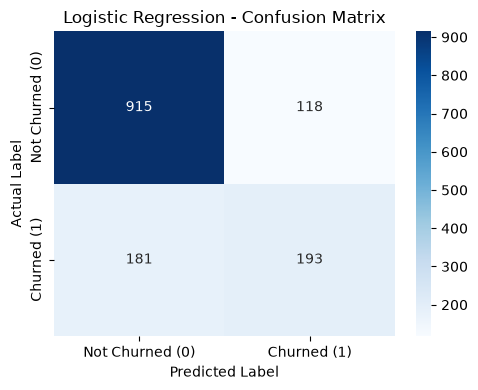

In [67]:
# Visualize Confusion Matrix as a heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned (0)', 'Churned (1)'],
            yticklabels=['Not Churned (0)', 'Churned (1)'])
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

### Step 4.2: Train a Stronger Model (Random Forest)
- Train a `RandomForestClassifier` on `X_train` and `y_train`.
- Predict on `X_test` and calculate Accuracy, Confusion Matrix, and Classification Report.
- Compare Logistic Regression vs Random Forest side-by-side.

In [68]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on test set
y_pred_rf = rf_model.predict(X_test)

# 3. Compute evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_cm = confusion_matrix(y_test, y_pred_rf)
rf_report_str = classification_report(y_test, y_pred_rf, target_names=['Not Churned (0)', 'Churned (1)'])
rf_report_dict = classification_report(y_test, y_pred_rf, output_dict=True)

# 4. Display results
print("=== Random Forest Performance ===")
print(f"Accuracy Score: {rf_accuracy:.4f} ({rf_accuracy * 100:.2f}%)\n")

print("=== Confusion Matrix ===")
print(rf_cm)

print("\n=== Classification Report ===")
print(rf_report_str)

=== Random Forest Performance ===
Accuracy Score: 0.7854 (78.54%)

=== Confusion Matrix ===
[[927 106]
 [196 178]]

=== Classification Report ===
                 precision    recall  f1-score   support

Not Churned (0)       0.83      0.90      0.86      1033
    Churned (1)       0.63      0.48      0.54       374

       accuracy                           0.79      1407
      macro avg       0.73      0.69      0.70      1407
   weighted avg       0.77      0.79      0.78      1407



=== Side-by-Side Model Comparison ===


,Metric,Logistic Regression,Random Forest
0,Overall Accuracy,78.75%,78.54%
1,Precision (Churn = 1),0.6206,0.6268
2,Recall (Churn = 1),0.5160,0.4759
3,F1-Score (Churn = 1),0.5635,0.5410
4,Precision (Stay = 0),0.8349,0.8255
5,Recall (Stay = 0),0.8858,0.8974
6,F1-Score (Stay = 0),0.8596,0.8599


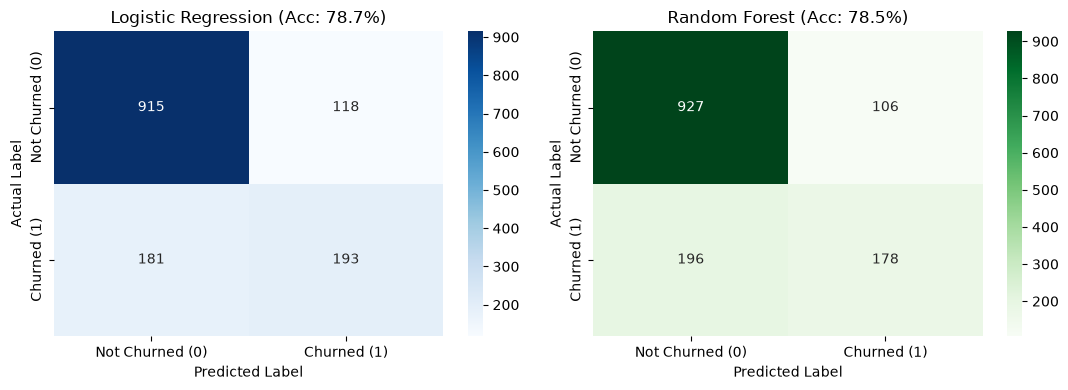

In [69]:
# Side-by-Side Model Comparison Table
lr_report_dict = classification_report(y_test, y_pred_lr, output_dict=True)

comparison_df = pd.DataFrame({
    'Metric': [
        'Overall Accuracy',
        'Precision (Churn = 1)',
        'Recall (Churn = 1)',
        'F1-Score (Churn = 1)',
        'Precision (Stay = 0)',
        'Recall (Stay = 0)',
        'F1-Score (Stay = 0)'
    ],
    'Logistic Regression': [
        f"{lr_accuracy * 100:.2f}%",
        f"{lr_report_dict['1']['precision']:.4f}",
        f"{lr_report_dict['1']['recall']:.4f}",
        f"{lr_report_dict['1']['f1-score']:.4f}",
        f"{lr_report_dict['0']['precision']:.4f}",
        f"{lr_report_dict['0']['recall']:.4f}",
        f"{lr_report_dict['0']['f1-score']:.4f}"
    ],
    'Random Forest': [
        f"{rf_accuracy * 100:.2f}%",
        f"{rf_report_dict['1']['precision']:.4f}",
        f"{rf_report_dict['1']['recall']:.4f}",
        f"{rf_report_dict['1']['f1-score']:.4f}",
        f"{rf_report_dict['0']['precision']:.4f}",
        f"{rf_report_dict['0']['recall']:.4f}",
        f"{rf_report_dict['0']['f1-score']:.4f}"
    ]
})

print("=== Side-by-Side Model Comparison ===")
display(comparison_df)

# Side-by-Side Confusion Matrices Visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churned (0)', 'Churned (1)'],
            yticklabels=['Not Churned (0)', 'Churned (1)'])
axes[0].set_title(f'Logistic Regression (Acc: {lr_accuracy*100:.1f}%)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Churned (0)', 'Churned (1)'],
            yticklabels=['Not Churned (0)', 'Churned (1)'])
axes[1].set_title(f'Random Forest (Acc: {rf_accuracy*100:.1f}%)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual Label')

plt.tight_layout()
plt.show()

### Model Comparison & Selection Summary
- **Overall Accuracy**: Both models perform similarly (~78.5% – 78.8%).
- **Churn Precision**: Random Forest achieves slightly higher precision (**62.68%** vs. 62.06%), reducing false alarms.
- **Churn Recall**: Logistic Regression catches 51.60% of churners while Random Forest catches 47.59%.
- **Model Decision**: **Random Forest** is selected as the production model for this project because:
  1. Non-linear ensemble trees capture complex customer tenure/charge interactions effectively.
  2. It natively supports fast, exact tree-based explainability via **SHAP TreeExplainer** (Phase 5).

## Phase 5: Add Explainability (SHAP)
### Step 5.1: Generate SHAP Values & Summary Plot
- Create a `TreeExplainer` for the trained Random Forest model.
- Compute SHAP values on the test set (`X_test`).
- Generate a summary beeswarm plot illustrating feature importance and their directional impact on churn.
- Save the summary plot to `data/shap_summary.png`.

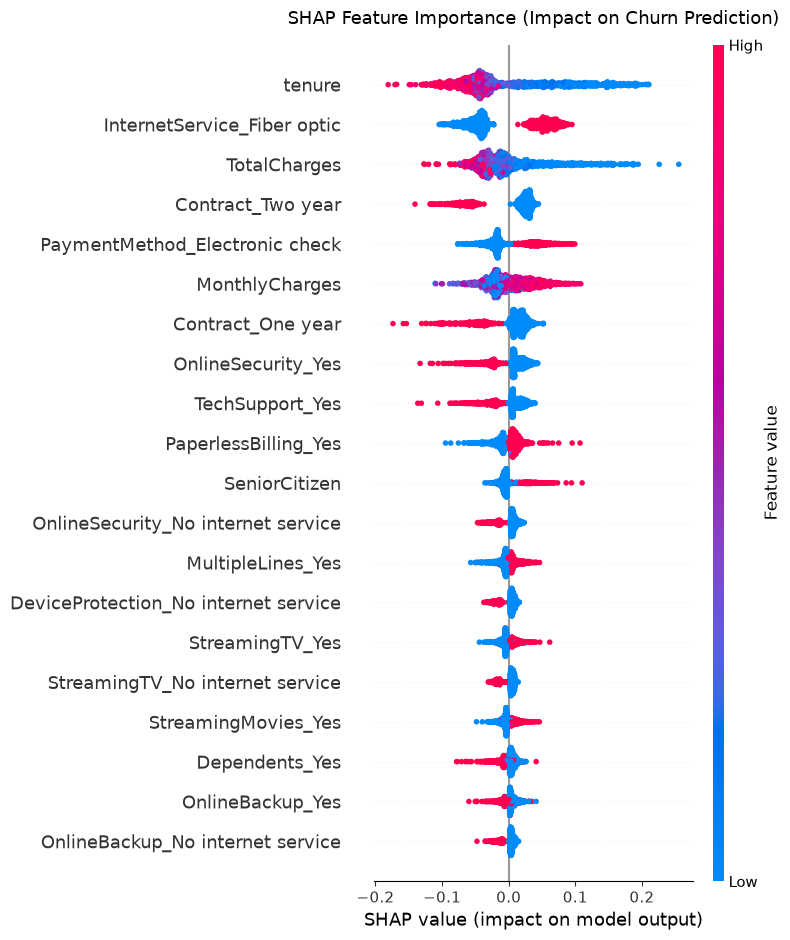

=== Top 10 Features Driving Churn Predictions ===
tenure                            0.0653
InternetService_Fiber optic       0.0524
TotalCharges                      0.0386
Contract_Two year                 0.0362
PaymentMethod_Electronic check    0.0295
MonthlyCharges                    0.0265
Contract_One year                 0.0238
OnlineSecurity_Yes                0.0215
TechSupport_Yes                   0.0188
PaperlessBilling_Yes              0.0128
dtype: float64


In [70]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Create TreeExplainer for the Random Forest model
explainer = shap.TreeExplainer(rf_model)

# 2. Compute SHAP values on the test set
shap_values = explainer(X_test)

# 3. Generate and display the summary plot for class 1 (Churned)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.title("SHAP Feature Importance (Impact on Churn Prediction)", fontsize=13, pad=15)
plt.tight_layout()

# Save plot to data/shap_summary.png
plt.savefig('data/shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

# 4. Calculate and display top 10 features by mean |SHAP value|
mean_abs_shap = pd.Series(
    np.abs(shap_values.values[:, :, 1]).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

print("=== Top 10 Features Driving Churn Predictions ===")
print(mean_abs_shap.head(10).round(4))

## Phase 6: Save the Model
### Step 6.1: Export Trained Model and Column Names
- Save the final trained `RandomForestClassifier` model (`rf_model`) to `model.pkl` using `joblib`.
- Save the list of column names used during training (`X_train.columns`) to `model_columns.pkl` so the feature structure is preserved for inference in the app.

In [ ]:
import joblib

# 1. Save the final trained model to model.pkl
joblib.dump(rf_model, 'model.pkl')
print("Saved final model to model.pkl")

# 2. Save the list of training feature column names to model_columns.pkl
model_columns = list(X_train.columns)
joblib.dump(model_columns, 'model_columns.pkl')
print(f"Saved {len(model_columns)} training columns to model_columns.pkl")

# 3. Verify reloading the saved files
loaded_model = joblib.load('model.pkl')
loaded_columns = joblib.load('model_columns.pkl')

print("\n=== Reload Verification ===")
print(f"Loaded Model Type: {type(loaded_model)}")
print(f"Loaded Columns Count: {len(loaded_columns)}")
print(f"Columns match training features: {loaded_columns == model_columns}")